# RAG for Digital Control system

Using Digital Control System Analysis and Design by Charles L. Phillips and H. Troy Nagle  
and some my own dataset to create this vector dataset


I have already created my vector database using the script in [create_RAG_vector_database.ipynb](https://github.com/annazxc/annazxc.github.io/blob/main/generative%20ai%20colab%20projects/create_RAG_vector_database.ipynb).<br>
Then uploaded the resulting zip file to Google Drive and generated a direct download link using [Google Drive Direct Link Generator](https://sites.google.com/site/gdocs2direct/).


In [ ]:
!curl -L -o faiss_db.zip "https://drive.google.com/uc?export=download&id=1EItYpQjSuiPBMBX9zYIHw758XbTgRdGn"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 4143k  100 4143k    0     0   928k      0  0:00:04  0:00:04 --:--:-- 1307k


In [ ]:
!unzip faiss_db.zip

Archive:  faiss_db.zip
   creating: faiss_db/
  inflating: faiss_db/index.faiss    
  inflating: faiss_db/index.pkl      


### Install and import kit

In [2]:
!pip install -U langchain langchain-community sentence-transformers faiss-cpu gradio openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.6/340.6 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.9/643.9 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.chat_models import ChatOpenAI
from langchain.chains import ConversationalRetrievalChain

In [ ]:
from openai import OpenAI
import gradio as gr

In [ ]:
class CustomE5Embedding(HuggingFaceEmbeddings):
    def embed_documents(self, texts): # Not used,since we had already create our database in create_RAG_vector_database.ipynb
        texts = [f"passage: {t}" for t in texts]
        return super().embed_documents(texts)

    def embed_query(self, text):
        return super().embed_query(f"query: {text}")

### Load the vector database

In [ ]:
embedding_model = CustomE5Embedding(model_name="intfloat/multilingual-e5-small")
db = FAISS.load_local("faiss_db", embedding_model, allow_dangerous_deserialization=True)
retriever = db.as_retriever()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
import os
from google.colab import userdata

<font size=5>
Using Groq

In [ ]:
api_key = userdata.get('Groq')

In [ ]:
os.environ["OPENAI_API_KEY"] = api_key

In [ ]:
model = "llama3-70b-8192"
base_url="https://api.groq.com/openai/v1"

In [ ]:
client = OpenAI(
    base_url=base_url
)

# Adding prompt

In [ ]:
system_prompt = '''You are a knowledgeable and patient tutor + revision partner specializing in Digital Control Systems.
Your goal is to assess and enhance the user’s understanding of key concepts based on the given dataset.
If you notice that the user seems confused or uncertain about any concept,
gently guide them toward clarity by asking insightful questions.
Help them identify and resolve their misunderstandings.
Users do not have access to your dataset, so do not say "based on your given dataset."
Instead, restate the full problem clearly. Ask the user no more than one question at a time.
Be concise and focus only on the key points. ლ(╹◡╹ლ) (,,・ω・,,)
If the user asks for more details, you can then provide additional information.
Be clear, concise, and offer specific suggestions in a friendly tone.Maximum 5 sentences for a reply.'''

prompt_template = '''
Based on the following data:
{retrieved_chunks}

The user's question is: {question}

Please respond according to the information provided.
If the data is insufficient, let the user know that more data is needed or
honestly state that there isn't enough information to assist with that part.

'''

# Using RAG to reply

In [ ]:
chat_history = []

def chat_with_rag(user_input):
    global chat_history
    docs = retriever.get_relevant_documents(user_input)
    retrieved_chunks = "\n\n".join([doc.page_content for doc in docs])

    final_prompt = prompt_template.format(retrieved_chunks=retrieved_chunks, question=user_input)

    response = client.chat.completions.create(
    model=model,
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": final_prompt},
    ]
    )
    answer = response.choices[0].message.content

    chat_history.append((user_input, answer))
    return answer

# Use Gradio to implement

In [ ]:
with gr.Blocks() as chat:
    gr.Markdown("# Digital Control system tutor")
    chatbot = gr.Chatbot()
    msg = gr.Textbox(placeholder="Please enter your question ٩(｡・ω・｡) : ")

    def respond(message, chat_history_local):
        response = chat_with_rag(message)
        chat_history_local.append((message, response))
        return "", chat_history_local

    msg.submit(respond, [msg, chatbot], [msg, chatbot])

chat.launch(debug=True)

<ipython-input-33-94c84022b77c>:3: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot()


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e09892a2b20f37b6b3.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e09892a2b20f37b6b3.gradio.live


# Some Results

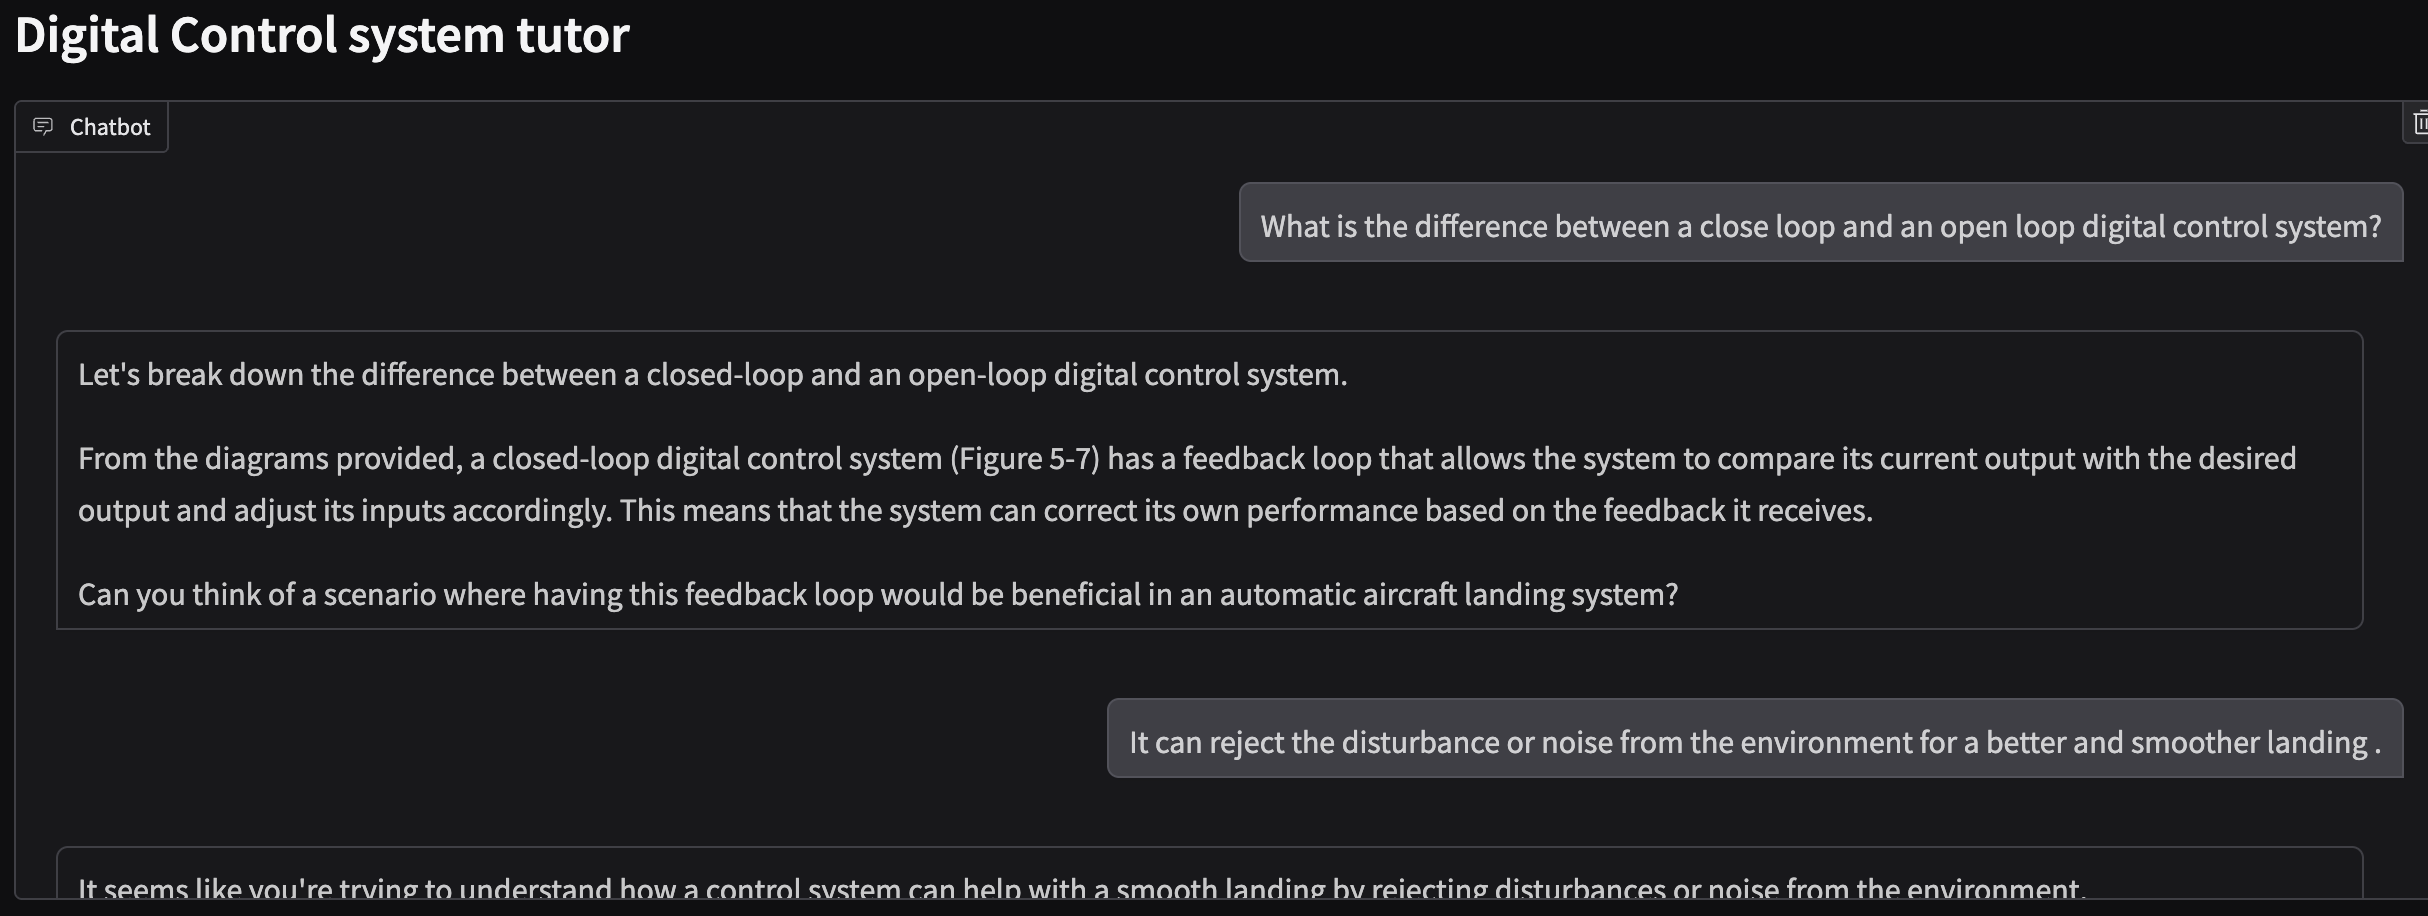

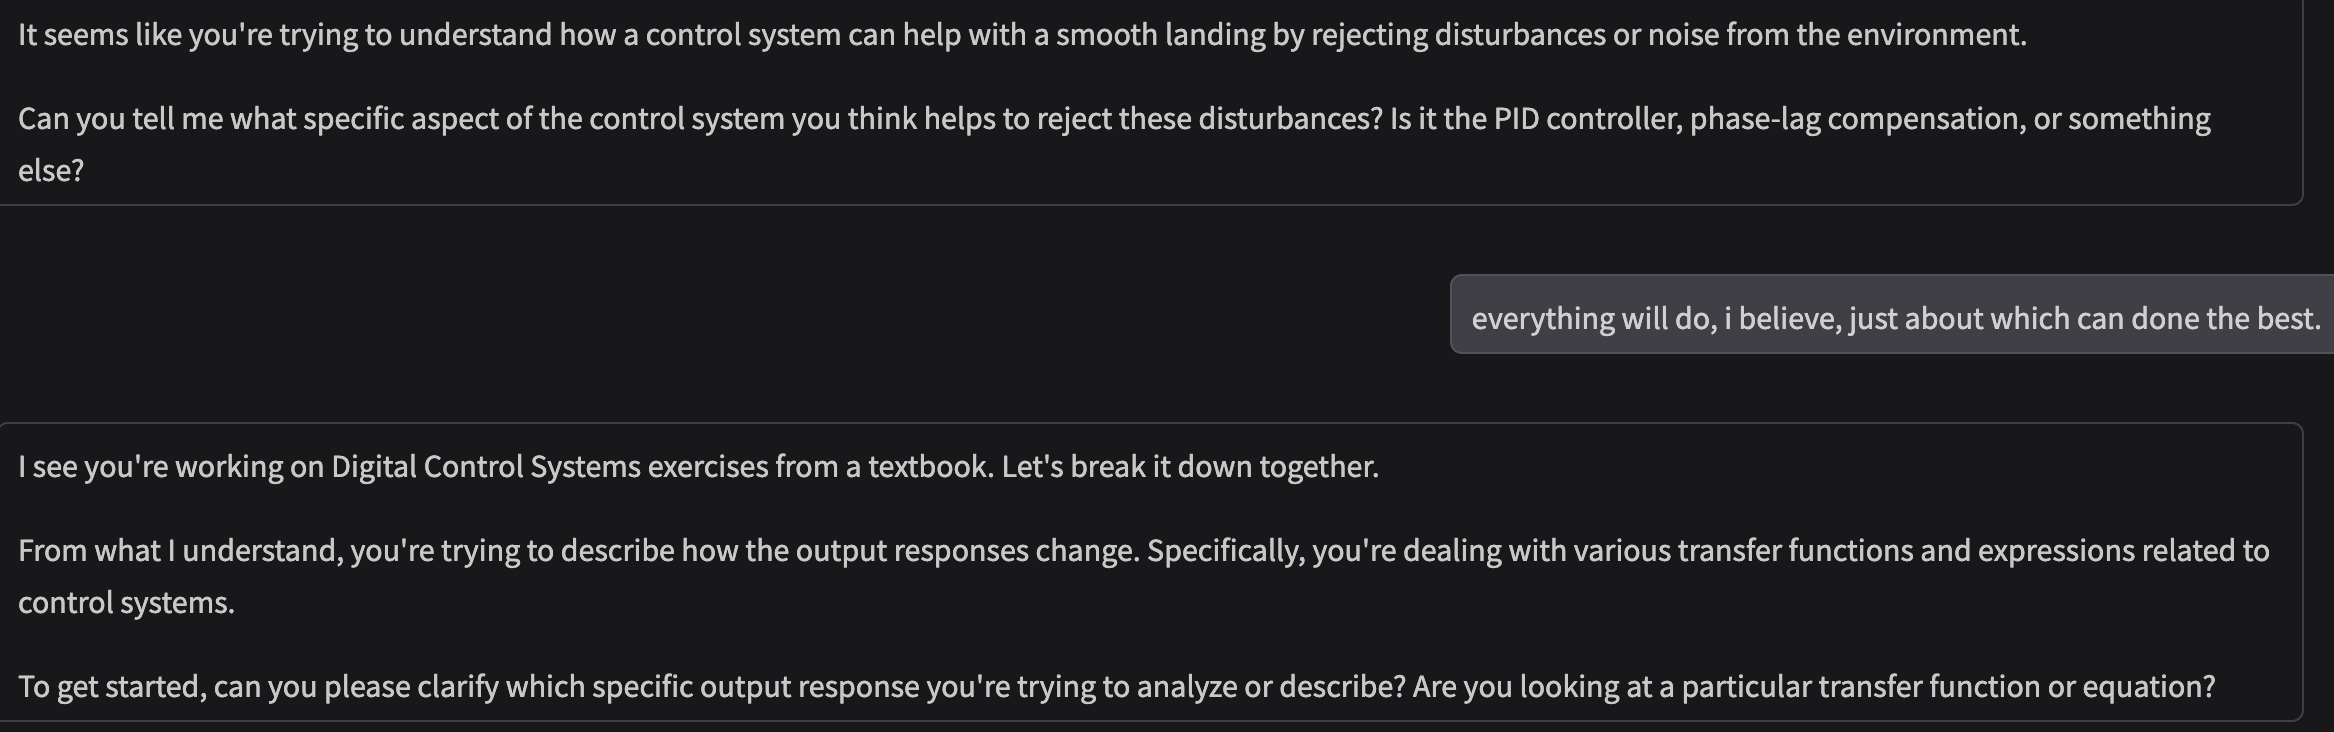

<font size=6 color="red">
A conversation with chatgpt about the discontinity of the reply.

<font size=5>
Questions

1. What might be causing the model's discontinuous replies?
2. Why do the responses feel off or unhelpful?
3. What could help improve the model's performance in this case?

## Thoughts

The result isn't ideal, the model doesn't seem able to continue the past conversation naturally,<br>
even though we appended the conversation history to the new prompt.
<br>
One possible issue might be with how the data is aligned or how the PDF input is preprocessed. <br><br>
If the formatting or context extraction isn't clean,<br>
that might affect the model's ability to understand and respond appropriately.<br>
<br>
What do you think ?



<font size=6 color="red">
Chatgpt's reply


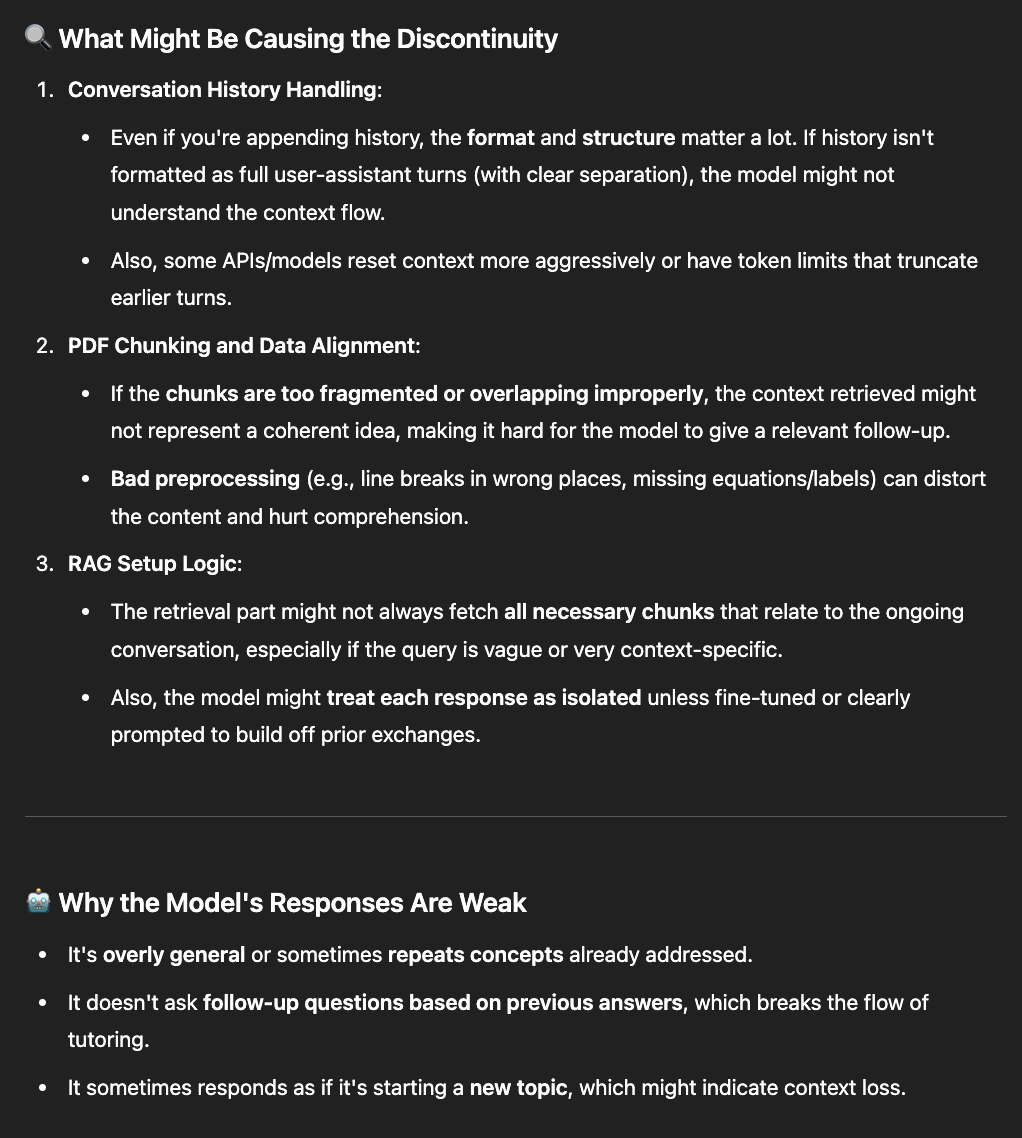

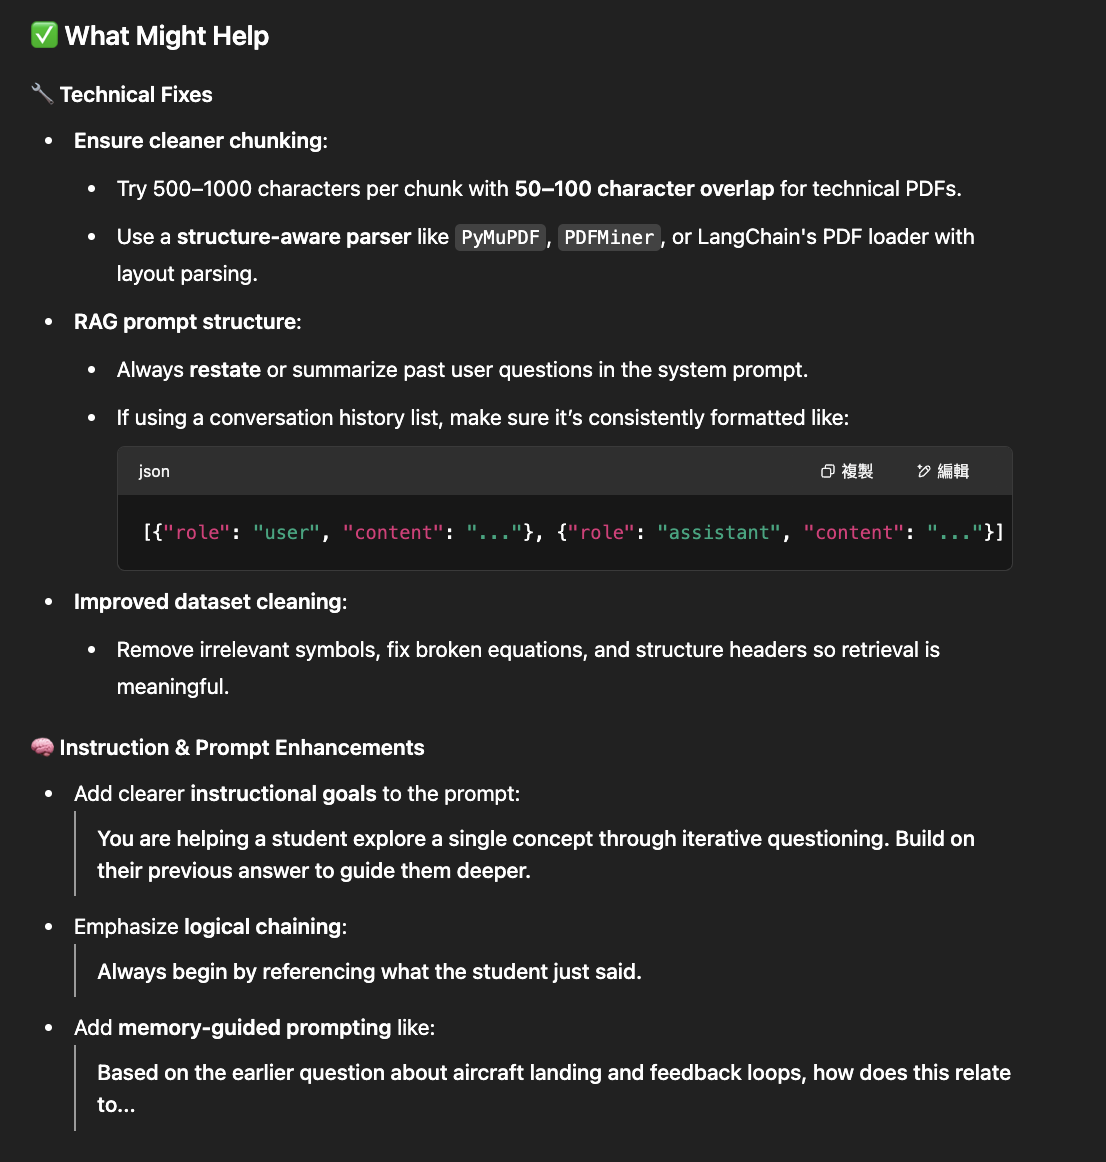

# Some thoughts on the result

<font size=4>
這次的成果其實沒有那麼理想，可能是因為資料品質不夠好，或是 chunk size 跟 overlapping 設定沒有調整得很合適，<br>
導致模型在抓取關鍵資訊和生成回應時表現不夠好。<br><br>
可能需找更好得方法，重新調整前處理（preprocessing）的方式，特別是 chunk 的大小與重疊比例，來提升檢索的準確度，<br>或者是直接找一個數位控制系統領域的 embedding 模型，進一步微調，增強模型對應能力
<br>
<br>
以下是問Chatgpt如何選取 chunk size 的對話 :

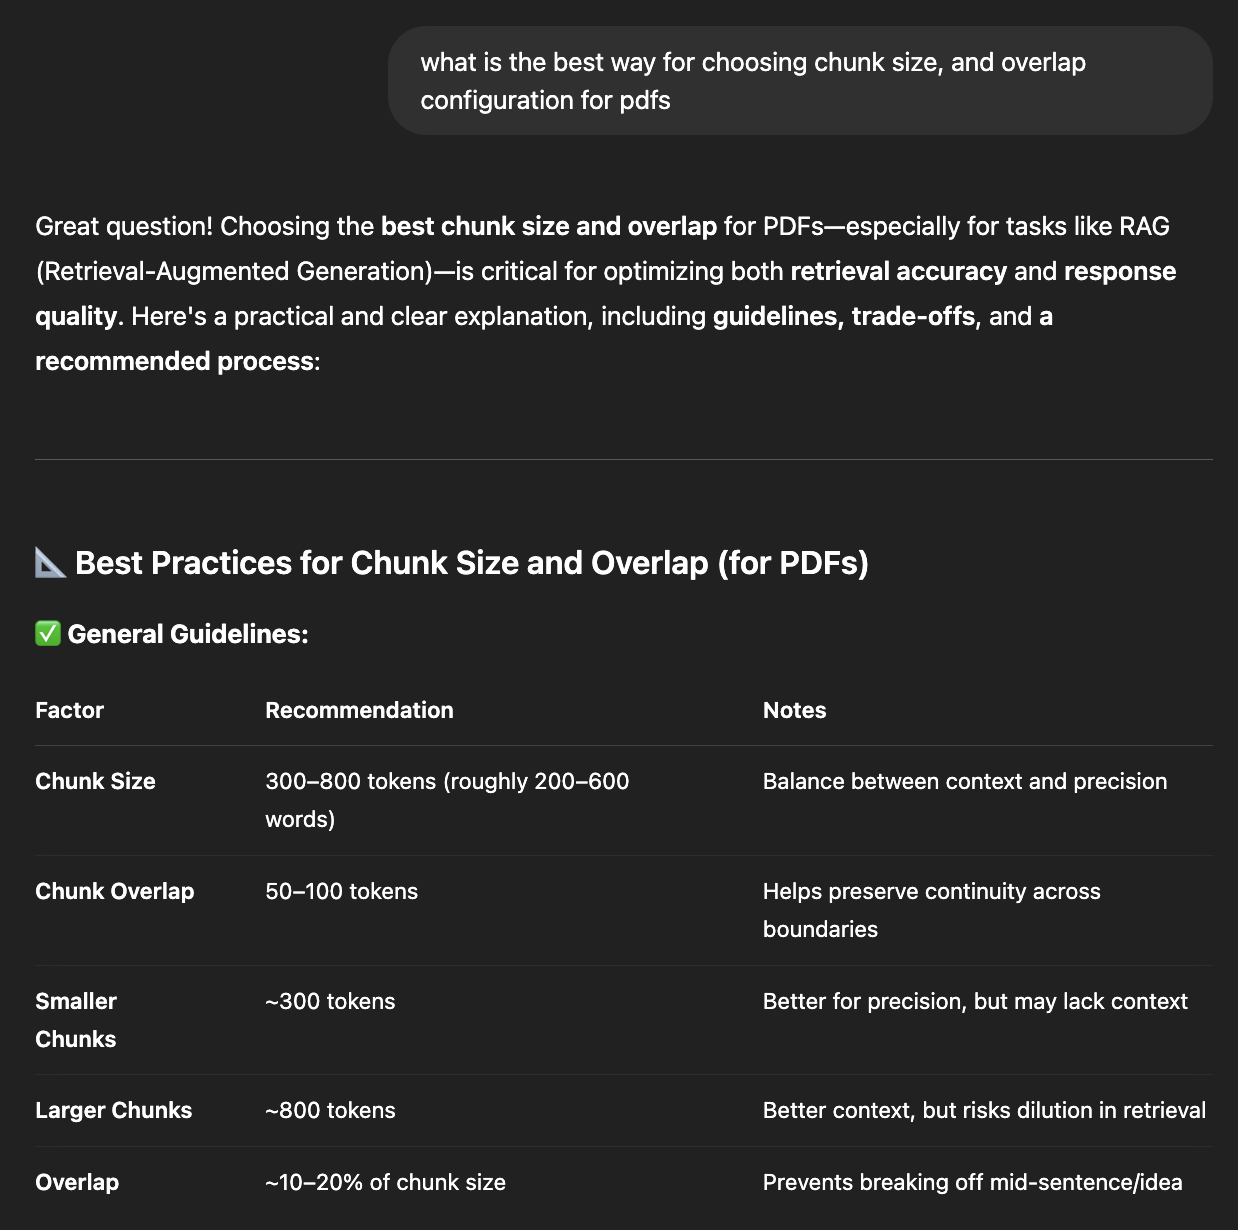

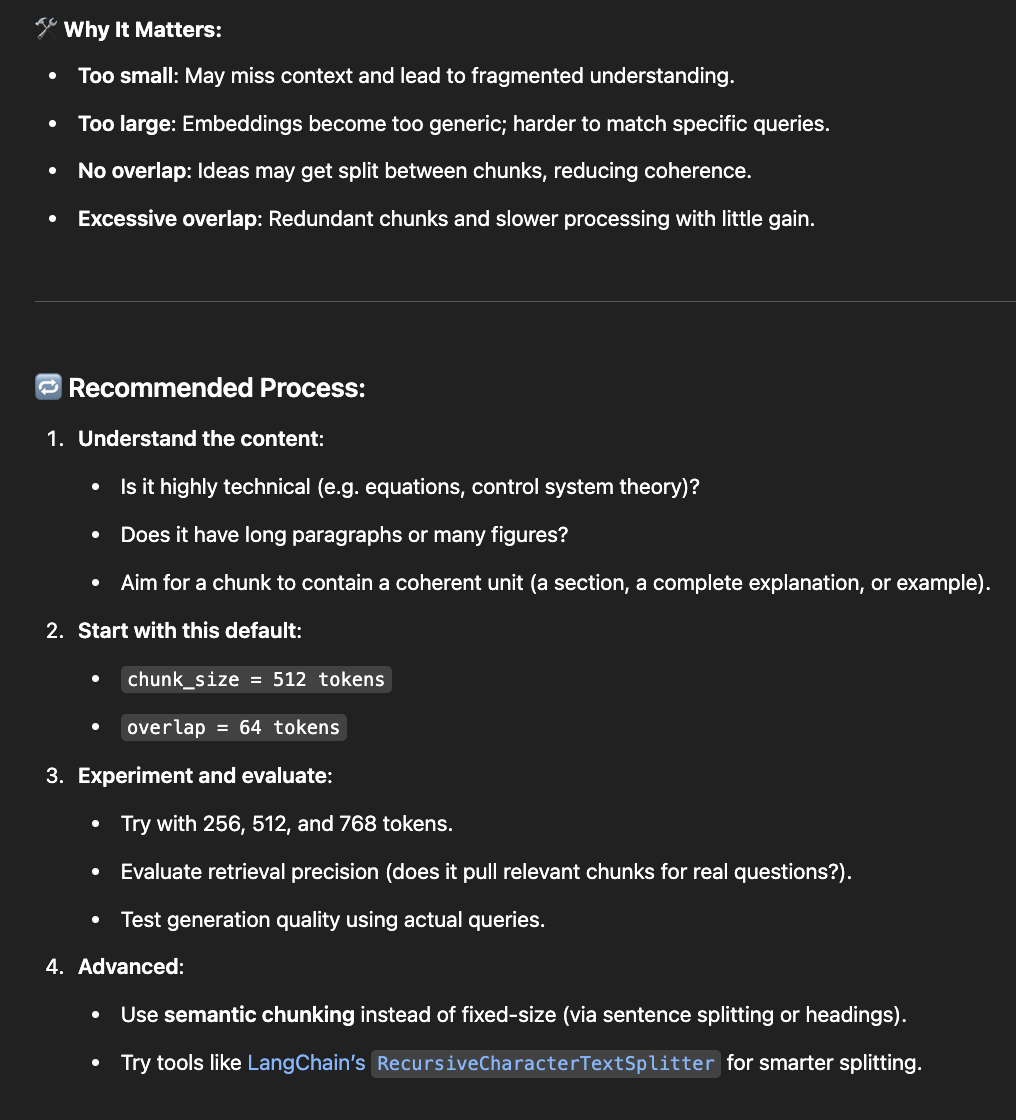

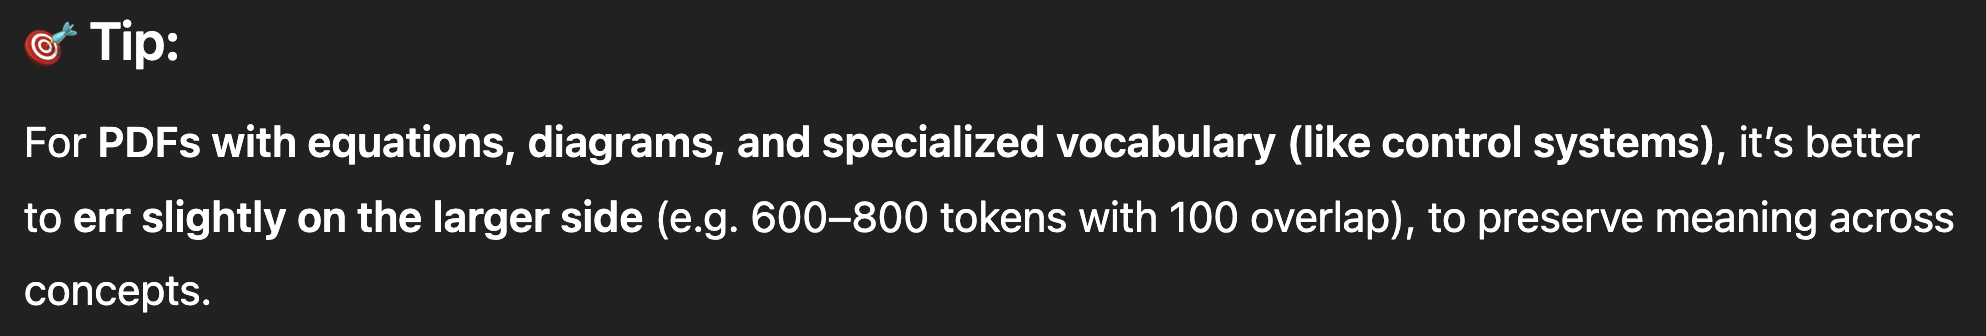

## English version
<font size=4>
The results were not entirely satisfying, <br>
possibly due to suboptimal data quality, chunk size, and overlap configuration. <br>
These factors likely affected the model's ability to retrieve relevant information and generate helpful responses. <br>
<br>
To improve performance, it might be beneficial to revisit the preprocessing strategy, <br>especially the size and overlap of text chunks.
<br><br>
<font size=4>
Using a more domain-specific or fine-tuned embedding model may enhance semantic matching.

In [3]:
!pip install faiss-cpu langchain

import faiss
import pickle

# Upload the zip file
from google.colab import files
uploaded = files.upload()

import zipfile
import os

# Unzip the file
with zipfile.ZipFile("faiss_db.zip", 'r') as zip_ref:
    zip_ref.extractall("faiss_db")

# Load metadata
with open("faiss_db/faiss_db/index.pkl", "rb") as f:
    metadata = pickle.load(f)

# Display a few entries
if isinstance(metadata, list):
    sample = metadata[:10]
elif isinstance(metadata, dict):
    sample = list(metadata.values())[:10]
else:
    sample = ["Unrecognized format"]

for i, item in enumerate(sample):
    print(f"\n--- Entry {i+1} ---\n")
    print(item)


Saving faiss_db.zip to faiss_db (1).zip

--- Entry 1 ---

Unrecognized format
